In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from flonacomldft.utils.io_utils import (
    load_pickle_file,
    get_path, 
    get_project_path
)

from flonacomldft.internal_coordinates import Coordinates_mapping, get_collective_variables_from_xs
from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    plot_energy_surface,
    plot_energy_histogram,
)

from numpy.lib.stride_tricks import sliding_window_view

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [3]:
# paths
DFT_DATA_PATH = get_path() + '/andersen/'
DFT_SIMS_PATH = get_project_path()

In [4]:
# simulation files
mcmc_paths = ['5-multimodal-mlp/results_multimodal_sampling_mixture_30544250/mixture_mcmc_dic_30544250.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30544251/mixture_mcmc_dic_30544251.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30544252/mixture_mcmc_dic_30544252.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30544253/mixture_mcmc_dic_30544253.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30544254/mixture_mcmc_dic_30544254.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30544255/mixture_mcmc_dic_30544255.pkl'
              ]

cvs_paths = ['5-multimodal-mlp/results_multimodal_sampling_mixture_30544250/cvs_mixture_30544250.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30544251/cvs_mixture_30544251.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30544252/cvs_mixture_30544252.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30544253/cvs_mixture_30544253.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30544254/cvs_mixture_30544254.pkl',
              '5-multimodal-mlp/results_multimodal_sampling_mixture_30544255/cvs_mixture_30544255.pkl'
              ]

# load mcmc results
keys = ['ab-flowMM slice {:d} MD {:d}'.format(i, j) for j in [500, 4000] for i in [5, 15, 30]]
print(keys)
color_keys = dict(zip(keys, ['blue', 'orange', 'red', 'green', 'purple', 'brown']))
mcmcs = {key: load_pickle_file(mcmc_path, DFT_SIMS_PATH) for mcmc_path, key in zip(mcmc_paths, keys)}
cvs = {key: load_pickle_file(cv_path, DFT_SIMS_PATH) for cv_path, key in zip(cvs_paths, keys)}

['ab-flowMM slice 5 MD 500', 'ab-flowMM slice 15 MD 500', 'ab-flowMM slice 30 MD 500', 'ab-flowMM slice 5 MD 4000', 'ab-flowMM slice 15 MD 4000', 'ab-flowMM slice 30 MD 4000']


In [5]:
# simulation files

mcmc_paths_dft = ['4-multimodal/results_multimodal_sampling_mixture_30540290/checkpoint_NA_3250.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_30540291/checkpoint_NA_3500.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_30540292/mixture_mcmc_dic_30540292.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_30540293/checkpoint_NA_2500.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_30540294/mixture_mcmc_dic_30540294.pkl',
              '4-multimodal/results_multimodal_sampling_mixture_30540295/mixture_mcmc_dic_30540295.pkl'
              ]

cvs_paths_dft = ['cvs_slices_30540290_3250.pkl',
           'cvs_slices_30540291_3500.pkl',
           '4-multimodal/results_multimodal_sampling_mixture_30540292/cvs_mixture_30540292.pkl',
           'cvs_slices_30540293_2500.pkl',
           '4-multimodal/results_multimodal_sampling_mixture_30540294/cvs_mixture_30540294.pkl',
           '4-multimodal/results_multimodal_sampling_mixture_30540295/cvs_mixture_30540295.pkl'
           ]

# load mcmc results
keys_dft = ['ab-flowMM w.o NP slice {:d} MD {:d}'.format(i, j) for j in [500, 4000] for i in [5, 15, 30]]
print(keys)
color_keys_dft = dict(zip(keys_dft, ['blue', 'orange', 'red', 'green', 'purple', 'brown']))
mcmcs_dft = {key: load_pickle_file(mcmc_path, DFT_SIMS_PATH) for mcmc_path, key in zip(mcmc_paths_dft, keys_dft)}
cvs_dft = {key: load_pickle_file(cvs_path, get_project_path()) for cvs_path, key in zip(cvs_paths_dft, keys_dft)}

['ab-flowMM slice 5 MD 500', 'ab-flowMM slice 15 MD 500', 'ab-flowMM slice 30 MD 500', 'ab-flowMM slice 5 MD 4000', 'ab-flowMM slice 15 MD 4000', 'ab-flowMM slice 30 MD 4000']


# Acceptance ratio

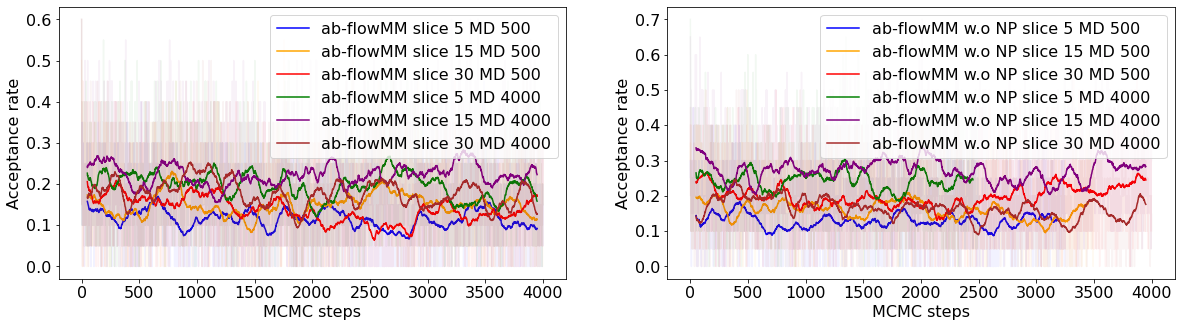

In [6]:
accs = {key: mcmcs[key]['accs'].float().mean(dim=1).detach() for key in mcmcs.keys()}
accs_dft = {key: mcmcs_dft[key]['accs'].float().mean(dim=1).detach() for key in mcmcs_dft.keys()}

fig, axs = plt.subplots(1, 2, figsize=(20, 5))

for ax, accs_, color_key in zip(axs, [accs, accs_dft], [color_keys, color_keys_dft]):

    for key in accs_.keys():
        set_plot_sequential_data(accs_[key], 
                                    ax=ax,
                                    window_size=100,
                                    alpha=0.05, 
                                    label=key, 
                                    color=color_key[key])
        ax.set_xlabel('MCMC steps')
        ax.set_ylabel('Acceptance rate')

        ax.legend()

# Collective variables

In [7]:
xs = {key: mcmcs[key]['xs'].detach() for key in mcmcs.keys()}
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

xs_dft = {key: mcmcs_dft[key]['xs'].detach() for key in mcmcs_dft.keys()}
isomers_dft = {key: mcmcs_dft[key]['isomers'] for key in mcmcs_dft.keys()}

In [8]:
isomer_colors = dict(zip([0, 1], ['cyan', 'salmon']))

In [9]:
cvs_isomers = {key: torch.cat((cvs[key], isomers[key].reshape(4000, 20, 1), 
                               #mcmcs[key]['us'].reshape(2000, 20, 1)
                               ), dim=2) for key in cvs.keys()}

cvs_isomers_dft = {key: torch.cat((cvs_dft[key], isomers_dft[key].reshape(isomers_dft[key].shape[0], 20, 1), 
                               #mcmcs[key]['us'].reshape(2000, 20, 1)
                               ), dim=2) for key in cvs_dft.keys()}

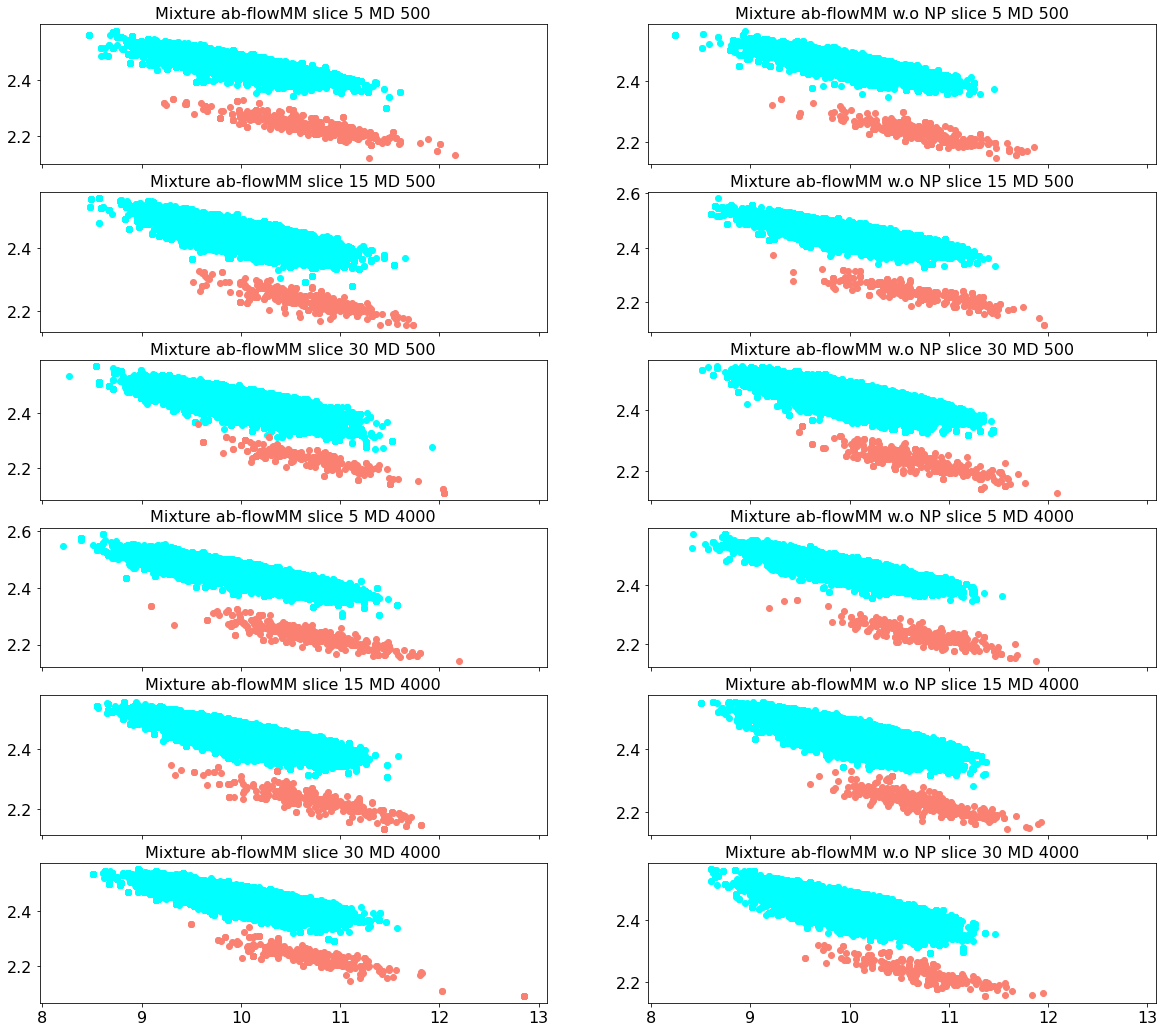

In [10]:
fig, axs = plt.subplots(len(keys), 2, figsize=(20, 3*len(keys)), sharex=True)

for i, cvs_ in enumerate([cvs_isomers, cvs_isomers_dft]):

    for j, key in enumerate(cvs_.keys()):
        for isomer in [0, 1]:
            mask = cvs_[key][:, :, 2] == isomer

            cvs_flatten = cvs_[key][mask].reshape(-1, 3)
            axs[j][i].scatter(cvs_flatten[:, 0], cvs_flatten[:, 1], 
                       label='Isomer {:d}'.format(isomer), color=isomer_colors[isomer])

        axs[j][i].set_title('Mixture {:s}'.format(key))
        #axs[j][i].set_xlabel('Radius of gyration')
        #axs[j][i].set_ylabel('Coordination number')

    #ax.set_xlim(8.5, 12)
    #ax.set_ylim(2.0, 2.6)

# Jumps along chains

Text(0.5, 0, 'Step')

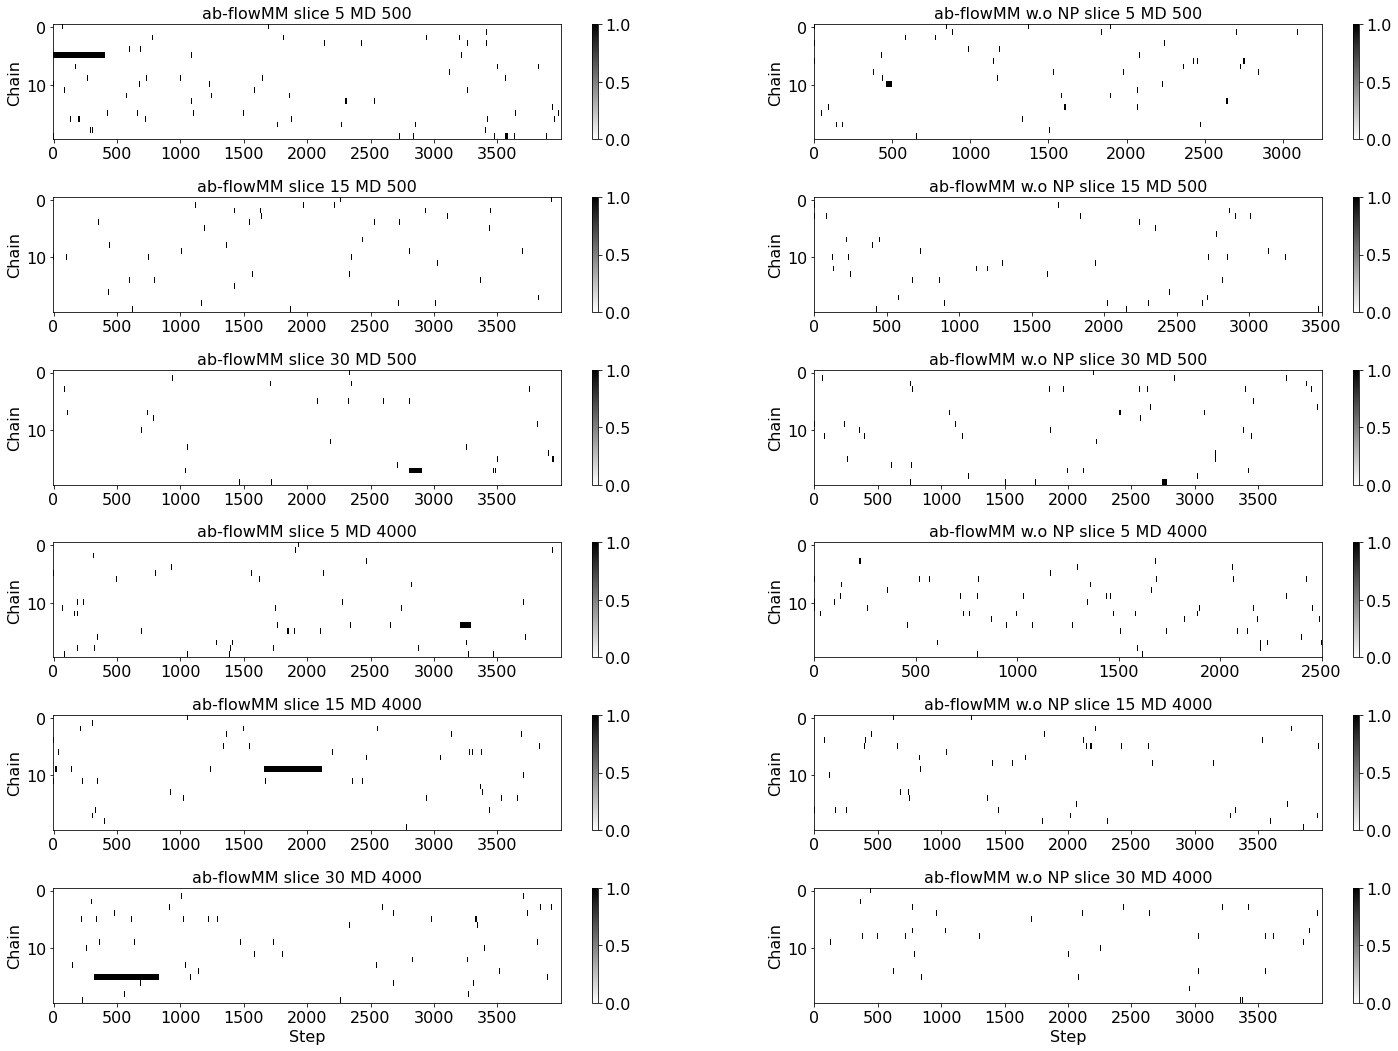

In [11]:
fig, axs = plt.subplots(len(keys), 2, figsize=(25, 3*len(keys)),
                        gridspec_kw={'hspace':0.5})#, sharex=False)

i=0
for keys_, isomers_ in zip([keys, keys_dft], [isomers, isomers_dft]):
    for j, key in enumerate(keys_):
        axs[j][i].imshow(isomers_[key].numpy().T, aspect='auto', cmap='gray_r', interpolation='none')
        #axs[j][i].set_xlabel('Step')
        axs[j][i].set_ylabel('Chain')
        axs[j][i].set_title(key)
        fig.colorbar(ax.imshow(isomers_[key].numpy().T, aspect='auto', cmap='gray_r', interpolation='none'), ax=axs[j][i])
        #if j!=5:
        #    plt.setp(axs[j][i].get_xticklabels(), visible=False)
    i=i+1

axs[-1][0].set_xlabel('Step')
axs[-1][1].set_xlabel('Step')

# Rhat

In [12]:
rhat = {key: R_hat(torch.cat((cvs[key].reshape(4000, 20, 2), mcmcs[key]['us'].reshape(4000, 20, 1)), dim=2).detach().numpy().transpose(1, 0, 2), 
                    labels=['Coordination number', 'Radius of gyration', 'Energy']) for key in keys if key != 'MD'}

rhat_dft = {key: R_hat(torch.cat((cvs_dft[key].reshape(cvs_dft[key].shape[0], 20, 2), mcmcs_dft[key]['us'].reshape(cvs_dft[key].shape[0], 20, 1)), dim=2).detach().numpy().transpose(1, 0, 2), 
                    labels=['Coordination number', 'Radius of gyration', 'Energy']) for key in keys_dft if key != 'MD'}

In [13]:
import matplotlib.patches as mpatches

patches = [mpatches.Patch(color=color_keys[keys[i]], label=keys[i]) for i in range(len(keys))]
patches_dft = [mpatches.Patch(color=color_keys_dft[keys_dft[i]], label=keys_dft[i]) for i in range(len(keys_dft))]

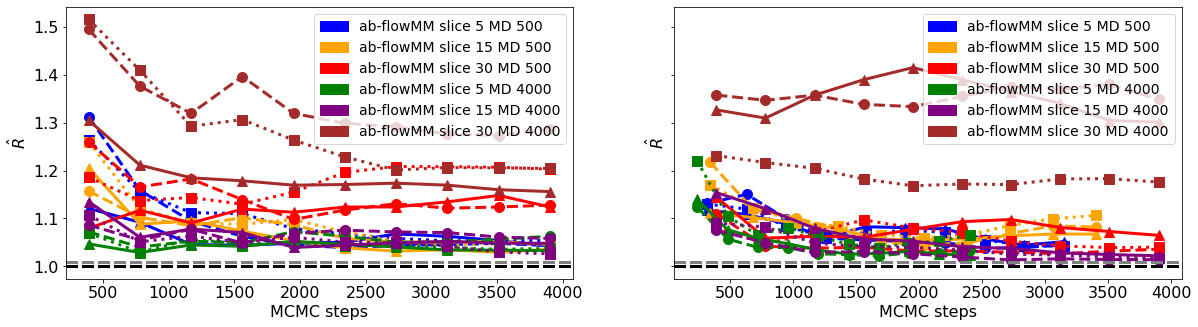

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

markers = ['o', 's', '^']
linestyles = ['dashed', 'dotted', '-']

for ax, rhat_, color_key, patches_ in zip(axs, [rhat, rhat_dft], [color_keys, color_keys_dft], [patches, patches_dft]):

    for key in rhat_.keys():
        for i in range(rhat_[key][0].shape[-1]):
            ax.plot(rhat_[key][1], 
                    rhat_[key][0][:, i], 
                    linestyle=linestyles[i], 
                    marker=markers[i],
                    markersize=10,
                    linewidth=3,
                    color=color_key[key], 
                    #label=rhat[key][2][i],
                    )

            ax.axhline(1, c='k', ls='--', linewidth=3)
            ax.axhline(1.01, c='grey', ls='--', linewidth=3)
            ax.set_xlabel('MCMC steps')
            ax.set_ylabel(r'$\hat{R}$')

        ax.legend(handles=patches, fontsize=14)

# Energies

ab-flowMM slice 5 MD 500 ab-flowMM w.o NP slice 5 MD 500
ab-flowMM slice 15 MD 500 ab-flowMM w.o NP slice 15 MD 500
ab-flowMM slice 30 MD 500 ab-flowMM w.o NP slice 30 MD 500
ab-flowMM slice 5 MD 4000 ab-flowMM w.o NP slice 5 MD 4000
ab-flowMM slice 15 MD 4000 ab-flowMM w.o NP slice 15 MD 4000
ab-flowMM slice 30 MD 4000 ab-flowMM w.o NP slice 30 MD 4000


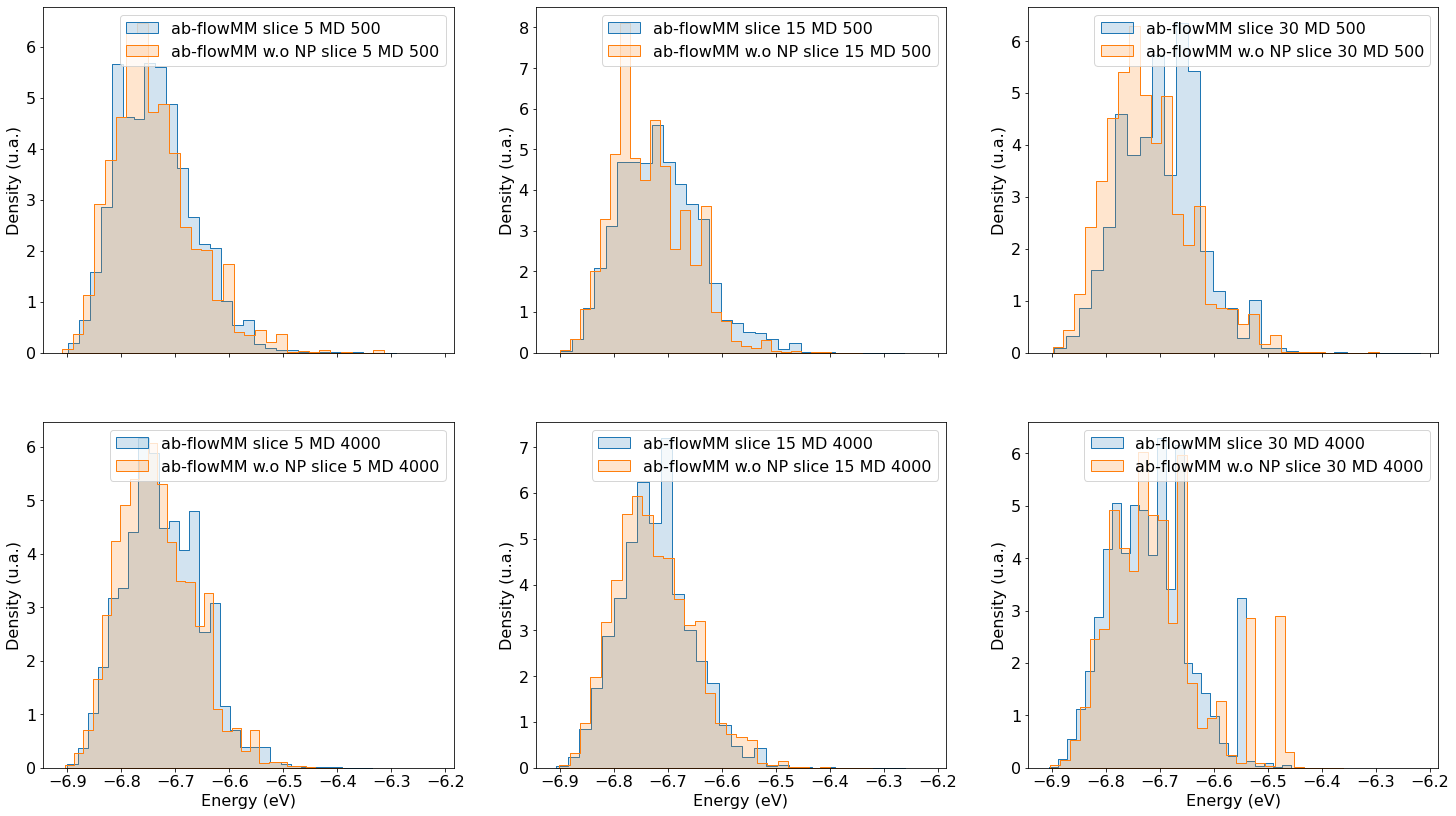

In [26]:
us = {key: mcmcs[key]['us'].flatten().detach() for key in mcmcs.keys()}
us_dft = {key: mcmcs_dft[key]['us'].flatten().detach() for key in mcmcs_dft.keys()}


fig, axs = plt.subplots(2, 3, figsize=(25, 7*2), sharex=True)
axs = axs.ravel()

for i in range(len(keys)):
    print(keys[i], keys_dft[i])

    plot_energy_histogram(us[keys[i]], 
                          ax=axs[i], 
                          bins=30, 
                          alpha=0.2, 
                          element='step',
                          common_bins=False, 
                          common_norm=False,
                          fill=True,
                          palette=color_keys,
                          label=keys[i])

    plot_energy_histogram(us_dft[keys_dft[i]], 
                          ax=axs[i], 
                          bins=30, 
                          alpha=0.2, 
                          element='step',
                          common_bins=False, 
                          common_norm=False,
                          fill=True,
                          palette=color_keys_dft,
                          label=keys_dft[i])
    
    axs[i].legend()

# Populations

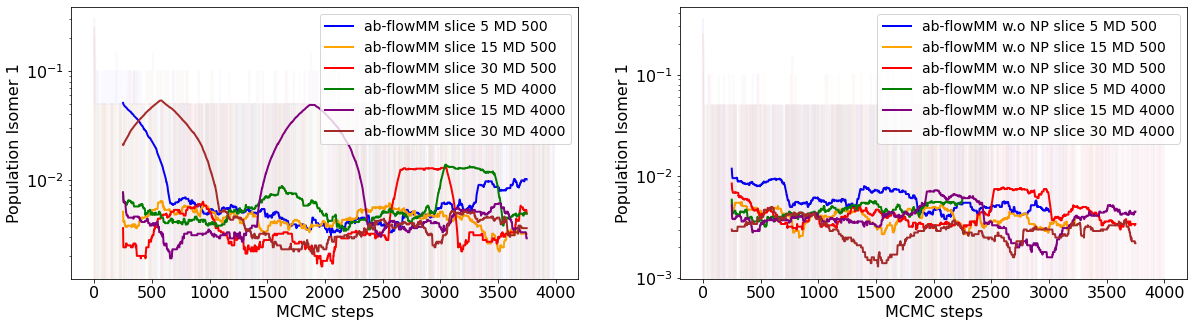

In [75]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))
n=0

for ax, isomers_, color_keys_ in zip(axs, [isomers, isomers_dft], [color_keys, color_keys_dft]):

    for key in isomers_.keys():
        set_plot_sequential_data(isomers_[key][n:, :].mean(dim=1).detach(), 
            avg=True, 
            window_size=500,
            ax=ax,
            linewidth=2,
            label=key, color=color_keys_[key], alpha=0.025)

        #ax.axhline(isomers[key][n:, :].mean().detach(), 0, 2000, 
        #            linestyle='--', color='red',
        #            label='Mean {:.1e}'.format(isomers[key][n:, :].mean().detach()) )

    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Population Isomer 1')
    ax.set_yscale('log')
    ax.legend(fontsize=14)

#ax.set_ylim(0, 0.01)